<h1 align="left">AlphaGenome Tutorial</h1>

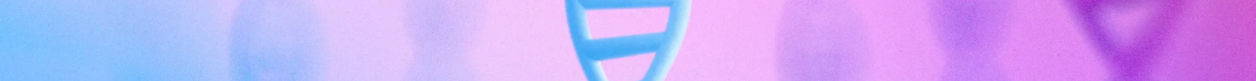

We now get familiar with outputs AlphaGenome can provide us. Let's ask him to do so!

# Part 2: Making Predictions

> **Nikita Vaulin**<br>
> PhD-student, Adameyko lab <br>
> tg: @nvaulin<br>
> nikita.vaulin@meduniwien.ac.at

### Contents
- [Section 1](#section-1)
- [Section 2](#section-2)


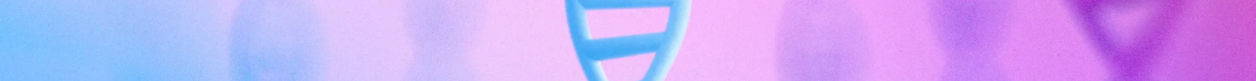

## 2.0. Setting up

In [72]:
import os
import random
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import alphagenome
from alphagenome.models import dna_client
from alphagenome.data import gene_annotation, genome, track_data, transcript
from alphagenome.visualization import plot_components 


print(alphagenome.__version__)

0.6.1


In [15]:
key = ! cat /home/nikita/tools/alphagenome_key.txt
dna_model = dna_client.create(key[0])

output_metadata = dna_model.output_metadata(organism = dna_client.Organism.HOMO_SAPIENS).concatenate()

## 2.1 Methods for prediction


With AlphaGenome you can do predictions in several ways:

<table style="margin:0">
<tr><th>Method</th><th>Input</th></tr>
<tr><td><code>predict_sequence</code></td><td>raw DNA string</td></tr>
<tr><td><code>predict_interval</code></td><td>genomic interval</td></tr>
<tr><td><code>predict_variant</code></td><td>interval + variant</td></tr>
</table>
</br>

Each method has a batch version accepting a list of inputs (`predict_sequences`, `predict_intervals`, `predict_variants`).


> Let's first focus on ***predict_sequence***
> 
### Required inputs

- **`sequence`** — DNA string of a supported length
- **`ontology_terms`** — Cell Ontology or UBERON CURIEs to select biosample tracks
- **`requested_outputs`** — list of `OutputType` values (`ATAC`, `DNASE`, `RNA`, `CHIP`, …)


## 2.2 Supported sequence lengths

AlphaGenome accepts sequences at 4 fixed lengths

In [16]:
for name, length in dna_client.SUPPORTED_SEQUENCE_LENGTHS.items():
    print(f"{name:25s}  {length:>10,} bp  ({length/1000:.0f} kb)")

SEQUENCE_LENGTH_16KB           16,384 bp  (16 kb)
SEQUENCE_LENGTH_100KB         131,072 bp  (131 kb)
SEQUENCE_LENGTH_500KB         524,288 bp  (524 kb)
SEQUENCE_LENGTH_1MB         1,048,576 bp  (1049 kb)


Shorter sequences must be expanded to one of the supported lengths:
- If you supply your own sequence (`predict_sequence`) — pad with `N` nucleotides.
- When working with `predict_interval` — the interval is expanded using surrounding genomic sequence.

> 💡 AlphaGenome team recommends using 1 MB sequences where possible for best results.

In [17]:
SEQ_LEN = dna_client.SEQUENCE_LENGTH_1MB
print(f'{SEQ_LEN = }')

SEQ_LEN = 1048576


## 2.3 Python string tricks 

When working with sequences, standard Python string operations are useful:

In [18]:
SEQ_LEN = 10 # for simplicity

#### 1) Random generation

In [19]:
seq = ''.join(random.choices('ACGT', k=SEQ_LEN))
print(f'{seq = }')

seq = 'TTCCAAGATT'


#### 2) Shuffle

In [20]:
seq = ''.join(random.sample(seq, len(seq)))
print(f'{seq = }')

seq = 'TTCATAGATC'


#### 3)  Concat / repeat

In [21]:
helf_len = SEQ_LEN // 2

# One can `+` (concatenate) strings
# and multiply `*` strings by a number (repeat)
seq = seq[:helf_len] + 'A' * helf_len 
print(f'{seq = }')

seq = 'TTCATAAAAA'


#### 4) Pad

In [22]:
seq = 'TATA'.center(SEQ_LEN, 'N')
print(f'{seq = }')

seq = 'NNNTATANNN'


## 2.4 Predict sequence

Now lets generate predictions for some input sequence. 

We also need to pick up an ONTOLOGY TERM and a OUTPUT TYPE to make a certain prediction.

In [23]:
SEQ_LEN = dna_client.SEQUENCE_LENGTH_1MB
seq = 'ATGTGCA'.center(SEQ_LEN, 'N')

In [24]:
output_metadata.query('ontology_curie == "CL:0000100"').reset_index(drop=True)

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean,output_type,gtex_tissue,histone_mark,transcription_factor
0,CL:0000100 ATAC-seq,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.273136,OutputType.ATAC,NaN,NaN,NaN
1,CL:0000100 total RNA-seq,.,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.036661,OutputType.RNA_SEQ,,NaN,NaN
2,CL:0000100 Histone ChIP-seq H3K27ac,.,Histone ChIP-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.707323,OutputType.CHIP_HISTONE,NaN,H3K27ac,NaN
3,CL:0000100 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.730239,OutputType.CHIP_HISTONE,NaN,H3K4me1,NaN
4,CL:0000100 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.529027,OutputType.CHIP_HISTONE,NaN,H3K4me3,NaN
5,usage_CL:0000100 total RNA-seq,+,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,,NaN,NaN
6,usage_CL:0000100 total RNA-seq,-,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,,NaN,NaN
7,junction_CL:0000100 total RNA-seq,NaN,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_JUNCTIONS,,NaN,NaN


In [25]:
output = dna_model.predict_sequence(sequence=seq,
                                    ontology_terms=['CL:0000100'], 
                                    requested_outputs=[dna_client.OutputType.RNA_SEQ],
)

print(type(output))
print(output)

<class 'alphagenome.models.dna_output.Output'>
Output(atac=None, cage=None, dnase=None, rna_seq=TrackData(values=array([[0.00072098],
       [0.00068283],
       [0.00062943],
       ...,
       [0.00072098],
       [0.00113678],
       [0.00159454]], shape=(1048576, 1), dtype=float32), metadata=                       name strand    Assay title ontology_curie  \
0  CL:0000100 total RNA-seq      .  total RNA-seq     CL:0000100   

  biosample_name                 biosample_type biosample_life_stage  \
0   motor neuron  in_vitro_differentiated_cells                adult   

  gtex_tissue data_source endedness  genetically_modified  nonzero_mean  
0                  encode    paired                 False      0.036661  , resolution=1, interval=None, uns=None), chip_histone=None, chip_tf=None, splice_sites=None, splice_site_usage=None, splice_junctions=None, contact_maps=None, procap=None)


In [26]:
output_rna = output.rna_seq

print(type(output_rna))

<class 'alphagenome.data.track_data.TrackData'>


## 2.5 TrackData — structure of the model output 

When the model makes a prediction, it returns a `TrackData` object for each output type.
Think of it as a **2D matrix of signal** — rows are genomic bins, columns are biological tracks (cell types / tissues).

The two core attributes are:
- **`.values`** — the actual predicted signal, a numpy array of shape `(bins, tracks)`
- **`.metadata`** — a DataFrame describing each track: which cell type, assay, tissue, strand…

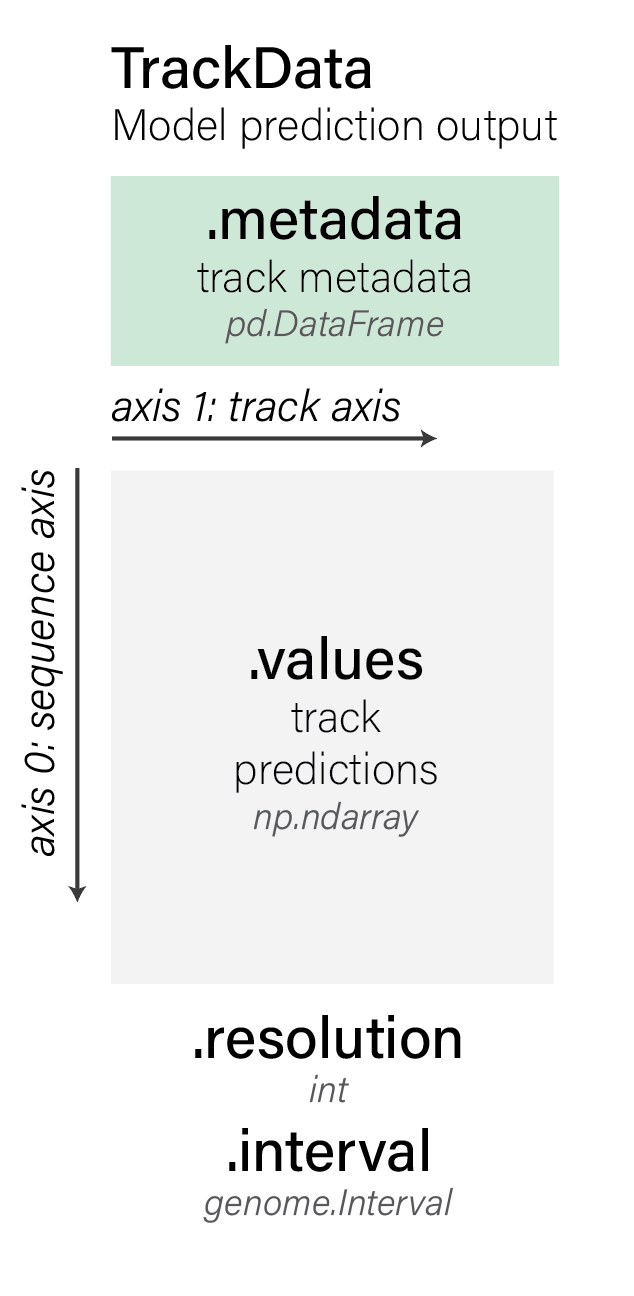


Each **bin** corresponds to a fixed genomic window (stored in `.resolution`). For example, here we got 1048576 numericall values for the requested 1-bp RNA-seq prediction.

In [27]:
print(output_rna.resolution)
print(output_rna.values.shape)
print()
output_rna.values

1
(1048576, 1)



array([[0.00072098],
       [0.00068283],
       [0.00062943],
       ...,
       [0.00072098],
       [0.00113678],
       [0.00159454]], shape=(1048576, 1), dtype=float32)

If you predicted for a real genomic locus, `.interval` tells you exactly where in the genome this window sits.

Beyond raw access, `TrackData` has methods to slice, filter, and resample:
you can subset to specific tracks by name or index, zoom into a sub-interval,
filter by strand, or change the bin resolution — all without leaving the object.

In [28]:
output_rna.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0000100 total RNA-seq,.,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,,encode,paired,False,0.036661


The cool thing is that one can ask for multiple predictions for a single DNA input:

In [33]:
output = dna_model.predict_sequence(sequence=seq,
                                    ontology_terms=['CL:0000100', 'CL:0000084'], # multiple ontologies
                                    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.ATAC], # multiple modalities
)

output_rna = output.rna_seq
output_atac = output.atac

In [36]:
print(output_rna.values.shape)
output_rna.metadata

(1048576, 5)


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0000084 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,paired,False,0.124296
1,CL:0000084 total RNA-seq,+,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,single,False,0.100934
2,CL:0000084 polyA plus RNA-seq,-,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,paired,False,0.124296
3,CL:0000084 total RNA-seq,-,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,single,False,0.100934
4,CL:0000100 total RNA-seq,.,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,,encode,paired,False,0.036661


In [37]:
print(output_atac.values.shape)
output_atac.metadata

(1048576, 2)


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0000084 ATAC-seq,.,ATAC-seq,CL:0000084,T-cell,primary_cell,adult,encode,paired,False,0.739741
1,CL:0000100 ATAC-seq,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.273136


## 2.6 Working with genomic intervals

When working with reference genomes (*hg38* for human or *mm10* for mouse) - one can easily operate sequences using reference itself.

### 2.6.1 `genome.Interval`

Main object to operate with here is [data.genome.Interval](https://www.alphagenomedocs.com/api/generated/alphagenome.data.genome.Interval.html#alphagenome.data.genome.Interval)

In [60]:
interval = genome.Interval('chr22', 36_150_498, 36_252_898)
print(interval)
interval

chr22:36150498-36252898:.


Interval(chromosome='chr22', start=36150498, end=36252898, strand='.', name='')

In [61]:
interval.width

102400

In [62]:
interval.to_pyranges_dict()

{'Chromosome': 'chr22',
 'Start': 36150498,
 'End': 36252898,
 'Name': '',
 'Strand': '.'}

There are multiple operations you can do with intervals:


*Resizing & shifting*
```python
interval.resize(500_000)        # resize around center
interval.pad(10_000)            # extend both sides
interval.shift(5_000)           # move along chromosome
interval.center()               # get center position
```

*Querying*
```python
interval.width                  # length in bp
interval.overlaps(other)        # bool
interval.contains(other)        # bool
interval.intersect(other)       # returns overlap Interval
```

*Strand*
```python
interval.as_unstranded()        # set strand to '.'
interval.swap_strand()          # + ↔ −
interval.negative_strand        # bool
```

*Conversions*
```python
interval.to_pyranges_dict()     # → dict for pyranges
genome.Interval.from_str('chr1:1000000-2000000')
```

Most usefull one is probably a *resize*, since with it you can get a 1MB sequence around any desired position.

In [56]:
interval = genome.Interval('chr22', 36_150_498, 36_252_898).resize(dna_client.SEQUENCE_LENGTH_1MB)
interval

Interval(chromosome='chr22', start=35677410, end=36725986, strand='.', name='')

In [58]:
interval.width

1048576

### 2.6.2 Reference annotation

Also, it is possible to navigate using genome annotation. DeepMind has preprocessed and stored both of them in a suitable format here:

In [39]:
HG38_GTF_FEATHER = (
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)
MM10_GTF_FEATHER = (
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'mm10/gencode.vM23.annotation.gtf.gz.feather'
)

In [42]:
gtf = pd.read_feather(HG38_GTF_FEATHER)

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(gene_annotation.filter_protein_coding(gtf), ['1'])
# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)
# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(gtf_transcript)
longest_transcript_extractor = transcript.TranscriptExtractor(gtf_longest_transcript)

In [64]:
gtf_longest_transcript.head(5)

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,havana_transcript,exon_number,exon_id,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl,gene_id_nopatch
1286,chr1,HAVANA,transcript,944202,959256,.,-,.,ENSG00000188976.11,protein_coding,...,OTTHUMT00000097869.2,None,None,HGNC:24517,OTTHUMG00000040720.2,None,ENSP00000317992.6,CCDS3.1,None,ENSG00000188976
1287,chr1,HAVANA,exon,959214,959256,.,-,.,ENSG00000188976.11,protein_coding,...,OTTHUMT00000097869.2,1,ENSE00001926296.2,HGNC:24517,OTTHUMG00000040720.2,None,ENSP00000317992.6,CCDS3.1,None,ENSG00000188976
1288,chr1,HAVANA,CDS,959214,959240,.,-,0,ENSG00000188976.11,protein_coding,...,OTTHUMT00000097869.2,1,ENSE00001926296.2,HGNC:24517,OTTHUMG00000040720.2,None,ENSP00000317992.6,CCDS3.1,None,ENSG00000188976
1289,chr1,HAVANA,start_codon,959237,959240,.,-,0,ENSG00000188976.11,protein_coding,...,OTTHUMT00000097869.2,1,ENSE00001926296.2,HGNC:24517,OTTHUMG00000040720.2,None,ENSP00000317992.6,CCDS3.1,None,ENSG00000188976
1290,chr1,HAVANA,exon,958928,959081,.,-,.,ENSG00000188976.11,protein_coding,...,OTTHUMT00000097869.2,2,ENSE00003591928.1,HGNC:24517,OTTHUMG00000040720.2,None,ENSP00000317992.6,CCDS3.1,None,ENSG00000188976


Then you can construct an interval just focusing on the gene of interest!

In [65]:
interval = gene_annotation.get_gene_interval(gtf, gene_symbol='S100B')
interval

Interval(chromosome='chr21', start=46598603, end=46605208, strand='-', name='S100B')

In [66]:
interval = interval.resize(dna_client.SEQUENCE_LENGTH_1MB)
interval

Interval(chromosome='chr21', start=46077617, end=47126193, strand='-', name='S100B')

## 2.7 Predicting on genomic intervals

With the `genome.Interval` you can easily run predictions for desired tracks with `predict_interval`:

In [71]:
output = dna_model.predict_interval(interval=interval,
                                    ontology_terms=['CL:0000100'], 
                                    organism = dna_client.Organism.HOMO_SAPIENS, 
                                    requested_outputs=[dna_client.OutputType.RNA_SEQ],
)
output_rna = output.rna_seq
print(output_rna.values.shape)
print(output_rna.values)
output_rna.metadata

(1048576, 1)
[[0.0090332 ]
 [0.00811768]
 [0.00665283]
 ...
 [0.00013638]
 [0.00014782]
 [0.00016117]]


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0000100 total RNA-seq,.,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,,encode,paired,False,0.036661


## 2.8 Visualising predictions

AlphaGenome has a built-in [plotting interface](https://www.alphagenomedocs.com/visualization_library_basics.html) centered around a single function:
```python
plot_components.plot(...)
```

The plot has three main ingredients:

**1. Components** — what to draw, one panel per component (***tracks***, contact maps, gene annotations…). </br>
Each component becomes a horizontal subplot stacked vertically.

**2. Interval** — the genomic window to focus on (acts as `xlim`). </br>
This can be narrower than the prediction window — useful for ***zooming in***.

**3. Annotations** — optional markers drawn across all panels (e.g. a variant position, a regulatory element).
```python
fig = plot_components.plot(
    components=[...],       # list of panels to show
    interval=interval,      # genomic focus window
    title="My locus",
    annotations=[...],      # optional: mark positions across all panels
)
```
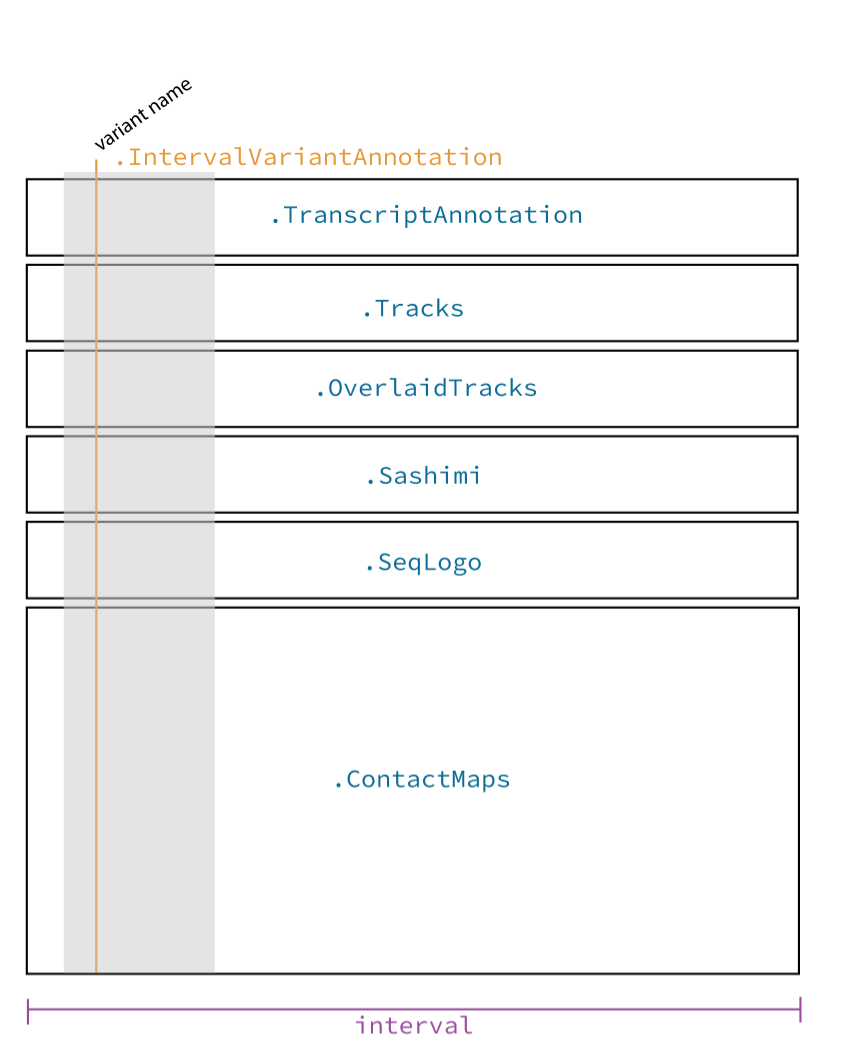

> 💡 Function returns [`matplotlib.figure.Figure`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure) so you can easily customise it!

The figure height is determined automatically as the sum of individual component heights,
scaled by `fig_height_scale`. Use `hspace` to control vertical spacing between panels.

In [75]:
transcripts = longest_transcript_extractor.extract(interval)

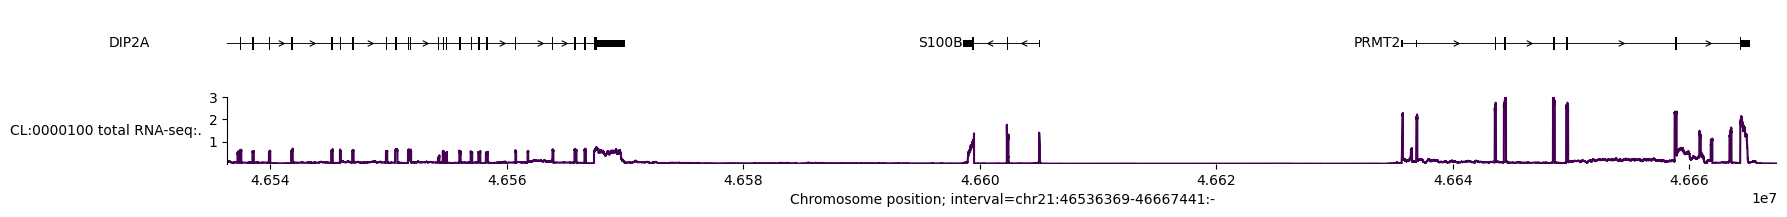

In [82]:
plot = plot_components.plot(
    interval=interval.resize(dna_client.SEQUENCE_LENGTH_100KB),
    components=[
                plot_components.TranscriptAnnotation(transcripts),
                plot_components.Tracks(output.rna_seq),
            ],
)

plt.show()

You can customise the plot by passing [certain parameters](https://www.alphagenomedocs.com/api/generated/alphagenome.visualization.plot_components.plot.html#alphagenome.visualization.plot_components.plot) or by working with `mpl.figure.Figure` object.

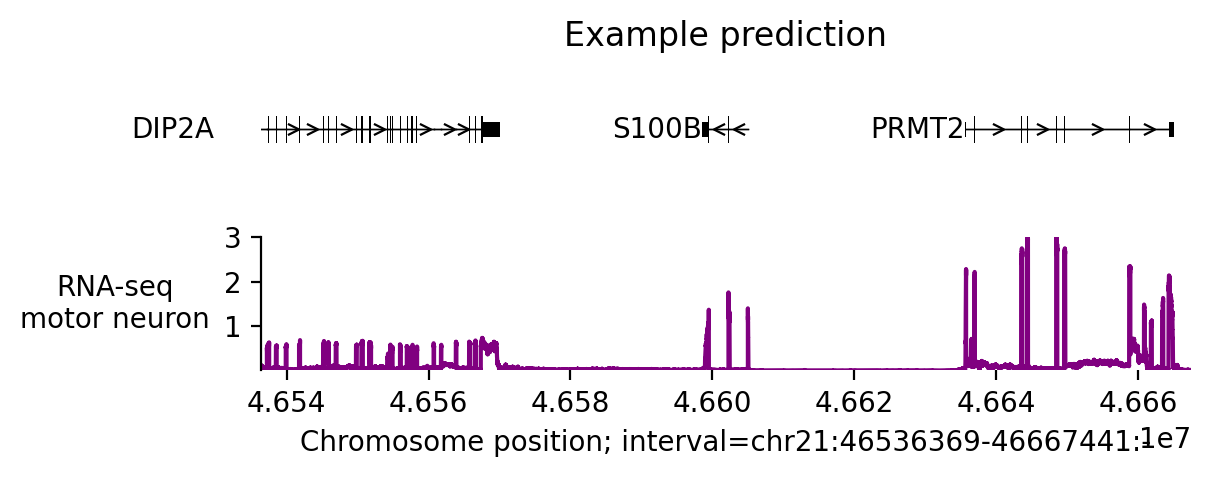

In [89]:
plot = plot_components.plot(
    interval=interval.resize(dna_client.SEQUENCE_LENGTH_100KB),
    components=[
                plot_components.TranscriptAnnotation(transcripts),
                plot_components.Tracks(output.rna_seq,
                                       track_colors ='purple',
                                       ylabel_template='RNA-seq\n{biosample_name}',
                                      ),
            ],
    fig_width=6,
    title='Example prediction'
)

plot.set_dpi(200)
plt.show()